# Part 4 - Homework 1

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib import cm
import time

## 1) implement N-M method, with dimension computed on the fly

In [7]:
def nelder_mead(x1, f, n_steps=1000, diameter=0.5, tol=1e-8):
    x = np.array(x1, dtype=float)
    n = len(x)
    
    #initialize the simplex
    simplex = np.zeros((n + 1, n))
    simplex[0] = x
    for i in range(n):
        step = np.zeros(n)
        step[i] = diameter
        simplex[i + 1] = x + step

    f_simplex = np.array([f(pt) for pt in simplex])
    # Track the best point's history
    x_hist, f_hist = [simplex[0].copy()], [f_simplex[0]]

    for _ in range(n_steps):
        # Sort the simplex
        order = np.argsort(f_simplex)
        simplex = simplex[order]
        f_simplex = f_simplex[order]
        
        x0 = simplex[0]    # Best point (X0)
        xw = simplex[-1]   # Worst point (Xw)

        x_hist.append(x0.copy())
        f_hist.append(f_simplex[0])
        
        # Check for convergence
        if np.max(np.abs(simplex[1:] - simplex[0])) <= tol:
            break
            
        # Centroid of all points EXCEPT the worst
        centroid = np.mean(simplex[:-1], axis=0)
        
        #REFLECT
        # Xr = Xw + 2(centroid - Xw)
        xr = xw + 2.0 * (centroid - xw)
        fxr = f(xr)
        
        if f_simplex[0] <= fxr < f_simplex[-2]:
            simplex[-1] = xr
            f_simplex[-1] = fxr
            continue
            
        #EXTEND
        if fxr < f_simplex[0]:
            # Xe = Xw + 3(centroid - Xw)
            xe = xw + 3.0 * (centroid - xw)
            fxe = f(xe)
            
            if fxe < fxr:
                simplex[-1] = xe
                f_simplex[-1] = fxe
            else:
                simplex[-1] = xr
                f_simplex[-1] = fxr
            continue
            
        #CONTRACTION
        if fxr < f_simplex[-1]:
            # OC: Xoc = Xw + 3/2(centroid - Xw)
            xoc = xw + 1.5 * (centroid - xw)
            fxoc = f(xoc)
            if fxoc <= fxr:
                simplex[-1] = xoc
                f_simplex[-1] = fxoc
                continue
        else:
            # IC: Xic = Xw + 1/2(centroid - Xw)
            xic = xw + 0.5 * (centroid - xw)
            fxic = f(xic)
            if fxic < f_simplex[-1]:
                simplex[-1] = xic
                f_simplex[-1] = fxic
                continue
                
        # SHRINK
        # Keep X0, replace all others: Xi' = 1/2(Xi + X0)
        for i in range(1, n + 1):
            simplex[i] = 0.5 * (simplex[i] + x0)
            f_simplex[i] = f(simplex[i])
            
    return np.array(x_hist), np.array(f_hist)

In [9]:
# f(x, y) = (x - 2)^2 + (y - 3)^2
def test_func(x):
    return (x[0] - 2)**2 + (x[1] - 3)**2

x_hist, f_hist = nelder_mead([0.0, 0.0], test_func)
print(f"Found minimum at {x_hist[-1]} with value {f_hist[-1]} in {len(x_hist)-1} iterations.")

Found minimum at [2. 3.] with value 9.698952188092613e-18 in 68 iterations.


## 2) Qualitatively compare Nelder-Mead method with the methods you have implemented in HW GD.2 

In [5]:
#NUMERICAL helper
def get_grad(f, x, eps=1e-5):
    """Numeric gradient fallback if analytical is not provided."""
    g = np.zeros_like(x)
    for i in range(len(x)):
        x1, x2 = x.copy(), x.copy()
        x1[i] += eps; x2[i] -= eps
        g[i] = (f(x1) - f(x2)) / (2 * eps)
    return g

#FUNCTIONS
def run_gd(x1, f, n_steps, gamma, grad=None):
    if grad is None: grad = lambda x: get_grad(f, x)
    x = np.array(x1, dtype=float)
    
    x_hist, f_hist = [x.copy()], [f(x)]
    for _ in range(n_steps):
        x = x - gamma * grad(x)
        x_hist.append(x.copy())
        f_hist.append(f(x))
    return np.array(x_hist), np.array(f_hist)

def run_polyak_gd(x1, f, n_steps, gamma, mu, grad=None):
    if grad is None: grad = lambda x: get_grad(f, x)
    x = np.array(x1, dtype=float)
    x_prev = x.copy()
    
    x_hist, f_hist = [x.copy()], [f(x)]
    for _ in range(n_steps):
        x_next = x - gamma * grad(x) + mu * (x - x_prev)
        x_prev = x.copy()
        x = x_next.copy()
        x_hist.append(x.copy())
        f_hist.append(f(x))
    return np.array(x_hist), np.array(f_hist)

def run_nesterov_gd(x1, f, n_steps, gamma, mu, grad=None):
    if grad is None: grad = lambda x: get_grad(f, x)
    x = np.array(x1, dtype=float)
    x_prev = x.copy()
    
    x_hist, f_hist = [x.copy()], [f(x)]
    for _ in range(n_steps):
        lookahead = x + mu * (x - x_prev)
        x_next = lookahead - gamma * grad(lookahead)
        x_prev = x.copy()
        x = x_next.copy()
        x_hist.append(x.copy())
        f_hist.append(f(x))
    return np.array(x_hist), np.array(f_hist)

def run_adagrad(x1, f, n_steps, gamma, eps=1e-8, grad=None):
    if grad is None: grad = lambda x: get_grad(f, x)
    x = np.array(x1, dtype=float)
    sq_grad_sum = np.zeros_like(x)
    
    x_hist, f_hist = [x.copy()], [f(x)]
    for _ in range(n_steps):
        g = grad(x)
        sq_grad_sum += g**2
        x = x - (gamma / (np.sqrt(sq_grad_sum) + eps)) * g
        x_hist.append(x.copy())
        f_hist.append(f(x))
    return np.array(x_hist), np.array(f_hist)

In [6]:
#NUMERIC helpers
def get_hess(f, x, eps=1e-5):
    """Numeric Hessian fallback with positive-definite adjustment."""
    n = len(x)
    H = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            x1, x2, x3, x4 = x.copy(), x.copy(), x.copy(), x.copy()
            x1[i] += eps; x1[j] += eps
            x2[i] += eps; x2[j] -= eps
            x3[i] -= eps; x3[j] += eps
            x4[i] -= eps; x4[j] -= eps
            H[i,j] = (f(x1) - f(x2) - f(x3) + f(x4)) / (4 * eps * eps)
    
    # Ensure Positive Definiteness
    eigvals = np.linalg.eigvalsh(H)
    if np.any(eigvals <= 0):
        H += (abs(np.min(eigvals)) + 1e-4) * np.eye(n)
    return H

def line_search(f, x, direction, grad, c=1e-4, rho=0.5):
    """Armijo condition backtracking line search."""
    alpha = 1.0
    while f(x + alpha * direction) > f(x) + c * alpha * np.dot(grad, direction):
        alpha *= rho
        if alpha < 1e-8: break # prevent infinite loops
    return alpha


#FUNCTIONS
def run_newton(x1, f, n_steps, grad=None, hess=None):
    if grad is None: grad = lambda x: get_grad(f, x)
    if hess is None: hess = lambda x: get_hess(f, x)
    x = np.array(x1, dtype=float)
    
    x_hist, f_hist = [x.copy()], [f(x)]
    for _ in range(n_steps):
        g = grad(x)
        if np.linalg.norm(g) < 1e-8: break
        
        H = hess(x)
        direction = -np.linalg.solve(H, g)
        alpha = line_search(f, x, direction, g)
        
        x = x + alpha * direction
        x_hist.append(x.copy())
        f_hist.append(f(x))
    return np.array(x_hist), np.array(f_hist)

def run_bfgs(x1, f, n_steps, grad=None):
    if grad is None: grad = lambda x: get_grad(f, x)
    x = np.array(x1, dtype=float)
    n = len(x)
    B = np.eye(n) # Initial inverse Hessian approx
    
    x_hist, f_hist = [x.copy()], [f(x)]
    for _ in range(n_steps):
        g = grad(x)
        if np.linalg.norm(g) < 1e-8: break
            
        direction = -np.dot(B, g)
        alpha = line_search(f, x, direction, g)
        
        x_next = x + alpha * direction
        g_next = grad(x_next)
        
        delta = x_next - x
        gamma_vec = g_next - g
        denom = np.dot(delta, gamma_vec)
        
        if denom > 1e-10:
            term1 = (np.outer(delta, gamma_vec) @ B + B @ np.outer(gamma_vec, delta)) / denom
            scalar = 1.0 + np.dot(gamma_vec, B @ gamma_vec) / denom
            term2 = scalar * (np.outer(delta, delta) / denom)
            B = B - term1 + term2
            
        x = x_next.copy()
        x_hist.append(x.copy())
        f_hist.append(f(x))
    return np.array(x_hist), np.array(f_hist)

**COMPARISON:**

In [10]:
def func_A(v):
    x, y, z = v
    return (x - z)**2 + (2*y + z)**2 + (4*x - 2*y + z)**2 + x + y

def func_B(v):
    x, y, z = v
    return (x - 1)**2 + (y - 1)**2 + 100*(y - x**2)**2 + 100*(z - y**2)**2

def func_C(v):
    x, y = v
    return (1.5 - x + x*y)**2 + (2.25 - x + x*y**2)**2 + (2.625 - x + x*y**3)**2

STARTS_A = [np.array([0.0, 0.0, 0.0]), np.array([1.0, 1.0, 0.0])]
STARTS_B = [np.array([1.2, 1.2, 1.2]), np.array([-1.0, 1.2, 1.2])]
STARTS_C = [np.array([1.0, 1.0]), np.array([4.5, 4.5])]

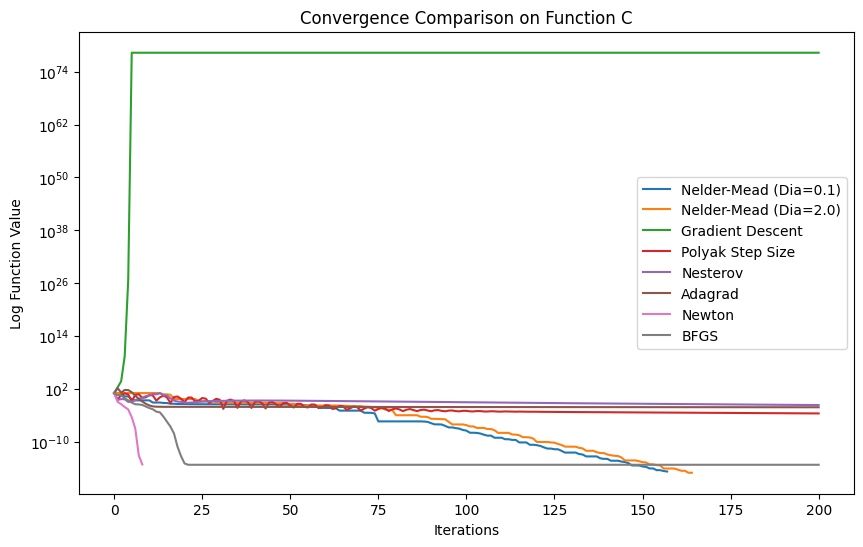

In [14]:
start = STARTS_B[0]
f = func_B
steps = 200
gamma = 0.001 # You'll need to tune gamma for GD per function!

# Run Algorithms
_, f_nm_small = nelder_mead(start, f, n_steps=steps, diameter=0.1)
_, f_nm_large = nelder_mead(start, f, n_steps=steps, diameter=2.0)
_, f_gd = run_gd(start, f, n_steps=steps, gamma=0.01)
_, f_polyak = run_polyak_gd(start, f, n_steps=steps, gamma=gamma, mu=0.9)
_, f_nesterov = run_nesterov_gd(start, f, n_steps=steps, gamma=gamma, mu=0.9)
_, f_adagrad = run_adagrad(start, f, n_steps=steps, gamma=0.5)
_, f_newton = run_newton(start, f, n_steps=steps)
_, f_bfgs = run_bfgs(start, f, n_steps=steps)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(f_nm_small, label='Nelder-Mead (Dia=0.1)')
plt.plot(f_nm_large, label='Nelder-Mead (Dia=2.0)')
plt.plot(f_gd, label='Gradient Descent')
plt.plot(f_polyak, label='Polyak Step Size')
plt.plot(f_nesterov, label='Nesterov')
plt.plot(f_adagrad, label='Adagrad')
plt.plot(f_newton, label='Newton')
plt.plot(f_bfgs, label='BFGS')

plt.yscale('log')
plt.title("Convergence Comparison on Function C")
plt.xlabel("Iterations")
plt.ylabel("Log Function Value")
plt.legend()
plt.show()

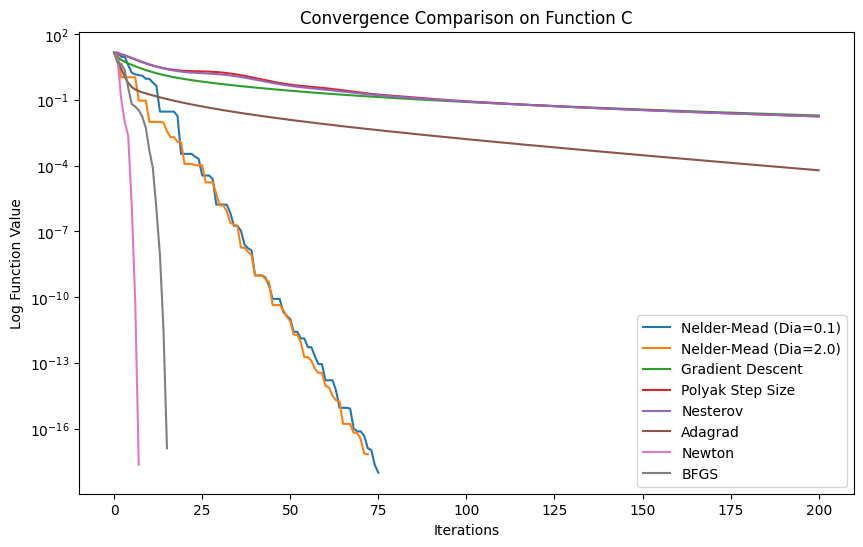

In [12]:
# Example: Testing Function C from the first starting point
start = STARTS_C[0]
f = func_C
steps = 200
gamma = 0.001 # You'll need to tune gamma for GD per function!

# Run Algorithms
_, f_nm_small = nelder_mead(start, f, n_steps=steps, diameter=0.1)
_, f_nm_large = nelder_mead(start, f, n_steps=steps, diameter=2.0)
_, f_gd = run_gd(start, f, n_steps=steps, gamma=0.01)
_, f_polyak = run_polyak_gd(start, f, n_steps=steps, gamma=gamma, mu=0.9)
_, f_nesterov = run_nesterov_gd(start, f, n_steps=steps, gamma=gamma, mu=0.9)
_, f_adagrad = run_adagrad(start, f, n_steps=steps, gamma=0.5)
_, f_newton = run_newton(start, f, n_steps=steps)
_, f_bfgs = run_bfgs(start, f, n_steps=steps)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(f_nm_small, label='Nelder-Mead (Dia=0.1)')
plt.plot(f_nm_large, label='Nelder-Mead (Dia=2.0)')
plt.plot(f_gd, label='Gradient Descent')
plt.plot(f_polyak, label='Polyak Step Size')
plt.plot(f_nesterov, label='Nesterov')
plt.plot(f_adagrad, label='Adagrad')
plt.plot(f_newton, label='Newton')
plt.plot(f_bfgs, label='BFGS')

plt.yscale('log')
plt.title("Convergence Comparison on Function C")
plt.xlabel("Iterations")
plt.ylabel("Log Function Value")
plt.legend()
plt.show()

In [18]:
def generate_comparison_table():
    # Number of iterations to run each algorithm
    N_STEPS = 500 
    
    # Configuration: (Function Name, Function Callable, Starting Points, Base Gamma)
    # Note: We assign a safe base learning rate (gamma) for each landscape
    configs = [
        ("Func A (Quadratic)", func_A, STARTS_A, 0.05),
        ("Func B (Rosenbrock)", func_B, STARTS_B, 0.001),
        ("Func C (Beale)", func_C, STARTS_C, 0.001)
    ]
    
    table_data = []
    
    for func_name, f, starts, gamma in configs:
        for i, start in enumerate(starts):
            # Format starting point for display
            start_str = f"[{', '.join([f'{x:.1f}' for x in start])}]"
            
            # 1. Run Nelder-Mead (Small and Large Diameters)
            _, f_nm_small = nelder_mead(start, f, n_steps=N_STEPS, diameter=0.1)
            _, f_nm_large = nelder_mead(start, f, n_steps=N_STEPS, diameter=2.0)
            
            # 2. Run First-Order Methods (Gradients)
            _, f_gd = run_gd(start, f, n_steps=N_STEPS, gamma=gamma)
            _, f_polyak = run_polyak_gd(start, f, n_steps=N_STEPS, gamma=gamma, mu=0.9)
            _, f_nesterov = run_nesterov_gd(start, f, n_steps=N_STEPS, gamma=gamma, mu=0.9)
            # AdaGrad usually requires a slightly larger learning rate to be effective
            _, f_adagrad = run_adagrad(start, f, n_steps=N_STEPS, gamma=gamma*10)
            
            # 3. Run Second-Order Methods (Hessians/Approximations)
            _, f_newton = run_newton(start, f, n_steps=N_STEPS)
            _, f_bfgs = run_bfgs(start, f, n_steps=N_STEPS)
            
            # Store the FINAL function value (last element in the f_hist array)
            # We use scientific notation formatting in Pandas later, so we just store raw floats here
            table_data.append({
                "Function": func_name,
                "Start": start_str,
                "NM (d=0.1)": f_nm_small[-1],
                "NM (d=2.0)": f_nm_large[-1],
                "GD": f_gd[-1],
                "Polyak": f_polyak[-1],
                "Nesterov": f_nesterov[-1],
                "AdaGrad": f_adagrad[-1],
                "Newton": f_newton[-1],
                "BFGS": f_bfgs[-1]
            })
            
    # Create the DataFrame
    df = pd.DataFrame(table_data)
    
    # Set multi-level index for cleaner presentation
    df = df.set_index(["Function", "Start"])
    
    return df

# Run the evaluation
results_df = generate_comparison_table()

# Display in Jupyter with scientific notation for readability 
# (Since values will range from 1e-12 to potentially massive numbers if they diverge)
display(results_df.style.format("{:.2e}"))